In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid", palette="viridis")

In [ ]:
try:
    data = pd.read_csv("sample_data/jalpaiguri_rice_detailed.csv")
    print("✅ Dataset loaded successfully!")
    display(data.head())
except FileNotFoundError:
    print("❌ Error: CSV not found.")

✅ Dataset loaded successfully!


,Year,District,Rice_Yield_t_ha,year,week_1_precip,week_1_LST,week_2_precip,week_2_LST,week_3_precip,week_3_LST,...,fortnight_7_precip,fortnight_7_LST,fortnight_8_precip,fortnight_8_LST,fortnight_9_precip,fortnight_9_LST,fortnight_10_precip,fortnight_10_LST,fortnight_11_precip,fortnight_11_LST
0,2001,Jalpaiguri,2.65,2001,0.0,24.787571,0.000000,25.285286,0.0,23.551000,...,0.188214,25.523143,1.253929,26.452214,0.000000,30.349214,2.303786,30.348000,4.977333,29.629167
1,2002,Jalpaiguri,2.72,2002,0.0,26.622000,0.000000,24.681286,0.0,23.016857,...,0.700286,24.559429,0.252143,26.588143,0.425071,28.318286,4.488714,16.873357,4.493833,28.782083
2,2003,Jalpaiguri,2.81,2003,0.0,25.684714,0.000000,27.015429,0.0,26.305000,...,1.882786,22.782929,0.201643,24.805714,1.821071,24.595571,0.973714,26.771500,2.847833,28.392667
3,2004,Jalpaiguri,2.93,2004,0.0,24.582571,0.000000,24.738143,0.0,23.604429,...,0.491500,24.886429,0.000000,25.358000,1.362714,28.350286,0.328214,26.527071,5.301385,24.549462
4,2005,Jalpaiguri,3.01,2005,0.0,24.600571,0.000714,26.061714,0.0,25.907000,...,0.110429,25.314000,0.432000,27.073857,2.203500,28.011714,1.664000,26.812286,1.533667,26.144250


In [ ]:
TARGET = "Rice_Yield_t_ha"

exclude_cols = ["Year", "District", TARGET, "year"]

feature_cols = [col for col in data.columns if col not in exclude_cols]

print(f"Identified {len(feature_cols)} feature columns.")
feature_cols

Identified 66 feature columns.


['week_1_precip',
 'week_1_LST',
 'week_2_precip',
 'week_2_LST',
 'week_3_precip',
 'week_3_LST',
 'week_4_precip',
 'week_4_LST',
 'week_5_precip',
 'week_5_LST',
 'week_6_precip',
 'week_6_LST',
 'week_7_precip',
 'week_7_LST',
 'week_8_precip',
 'week_8_LST',
 'week_9_precip',
 'week_9_LST',
 'week_10_precip',
 'week_10_LST',
 'week_11_precip',
 'week_11_LST',
 'week_12_precip',
 'week_12_LST',
 'week_13_precip',
 'week_13_LST',
 'week_14_precip',
 'week_14_LST',
 'week_15_precip',
 'week_15_LST',
 'week_16_precip',
 'week_16_LST',
 'week_17_precip',
 'week_17_LST',
 'week_18_precip',
 'week_18_LST',
 'week_19_precip',
 'week_19_LST',
 'week_20_precip',
 'week_20_LST',
 'week_21_precip',
 'week_21_LST',
 'week_22_precip',
 'week_22_LST',
 'fortnight_1_precip',
 'fortnight_1_LST',
 'fortnight_2_precip',
 'fortnight_2_LST',
 'fortnight_3_precip',
 'fortnight_3_LST',
 'fortnight_4_precip',
 'fortnight_4_LST',
 'fortnight_5_precip',
 'fortnight_5_LST',
 'fortnight_6_precip',
 'fortnigh

In [ ]:
original_features = feature_cols.copy()

weeks = sorted(list(set([
    int(col.split('_')[1]) for col in feature_cols if "week_" in col
])))

num_weeks = len(weeks)
print(f"Detected {num_weeks} weeks.")

# FIX: explicitly set features per week
features_per_week = 2
print(f"Detected {features_per_week} features per week.")

X_seq = []

for _, row in data.iterrows():
    seq = []
    for w in weeks:
        seq.append([
            row[f"week_{w}_precip"],
            row[f"week_{w}_LST"]
        ])
    X_seq.append(seq)

X_seq = np.array(X_seq)
y = data[TARGET].values

print("Final CNN input shape:", X_seq.shape)

Detected 22 weeks.
Detected 2 features per week.
Final CNN input shape: (24, 22, 2)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_r = X_train.reshape(-1, features_per_week)
X_test_r  = X_test.reshape(-1, features_per_week)

scaler.fit(X_train_r)

X_train_scaled = scaler.transform(X_train_r).reshape(X_train.shape)
X_test_scaled  = scaler.transform(X_test_r).reshape(X_test.shape)

print("Scaling completed.")

Scaling completed.


In [ ]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (19, 22, 2)
X_test_scaled shape: (5, 22, 2)


In [ ]:
model = Sequential([

    Conv1D(filters=64, kernel_size=2, activation='relu',
           input_shape=(num_weeks, features_per_week)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=32, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 21, 64)         │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 9, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,817 (57.88 KB)

 Trainable params: 14,817 (57.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor='val_loss',
    mode='min'
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 8.2768 - mae: 2.8679 - val_loss: 7.7481 - val_mae: 2.7738
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 7.5244 - mae: 2.7387 - val_loss: 7.5132 - val_mae: 2.7314
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 7.4241 - mae: 2.7212 - val_loss: 7.2675 - val_mae: 2.6860
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 7.0134 - mae: 2.6426 - val_loss: 7.0021 - val_mae: 2.6361
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 6.5479 - mae: 2.5526 - val_loss: 6.6997 - val_mae: 2.5779
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 6.1173 - mae: 2.4605 - val_loss: 6.3675 - val_mae: 2.5123
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 5.7518 - mae: 2.3892 - val_loss: 6.0052 - val_mae: 2.4386
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 5.3218 - mae: 2.2862 - val_loss: 5.6024 - val_mae: 2.3538
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 4.8897 - mae: 2.


📈 CNN Evaluation Results:
MAE: 0.2037
MSE: 0.0767
R2 Score: -1.2475


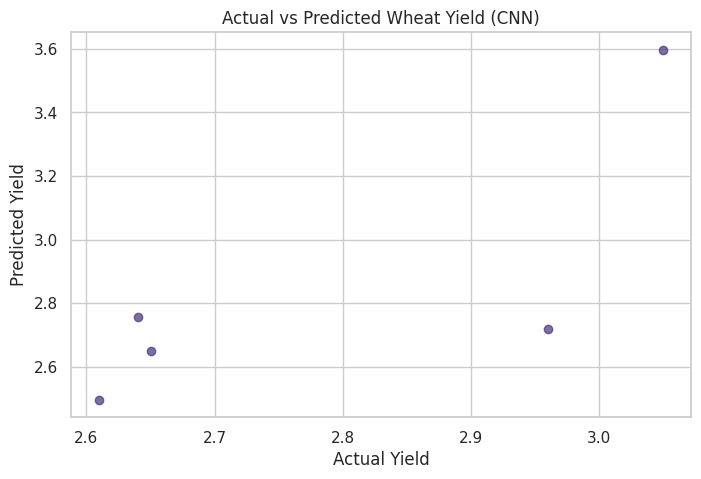

In [ ]:
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print("\n📈 CNN Evaluation Results:")
print(f"MAE: {mae:.4f}")

y_pred = model.predict(X_test_scaled, verbose=0)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Wheat Yield (CNN)")
plt.show()